# MeteoScreening from database (influxdb)

---
**Notebook version**: `11` (2 Sep 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw meteo data from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses [`StepwiseMeteoScreeningDb`](../diive/preprocessing/qaqc/meteoscreening.py) from [diive](https://github.com/holukas/diive). Download and upload use diive's InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`), which needs `uv sync --group db`.

**Flow:** download (`InfluxIO`) → screen on high-res data (`diive`) → resample to 30MIN → upload.

**Screening is stepwise.** Run a test, look at its preview, then commit it with `mscr.addflag()`. Run only the methods your variable needs. At the end all committed flags are aggregated into one quality flag `QCF`.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. The stamp marks the end of the averaging interval. This has to be right, because the day/night split during screening and the value written back to the database both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS`, set in *User settings*. It is applied the same way on download and on upload:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp. Set `TIMEZONE_OFFSET_TO_UTC_HOURS` to the timezone the raw data was logged in (for example `1` for CET winter time). The notebook prints the timestamps after the download and after the check download so you can confirm them.

This also affects manual removal. Removal is matched against `TIMESTAMP_MID`, so a single timestamp matches no record and removes nothing. Write a single record as a range that brackets it.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening.

**Variables to screen**
- `FIELDS`: variable name(s) exactly as stored in the database (the InfluxDB `_field`). Several are allowed.
- `MEASUREMENT`: exactly **one** measurement that groups those variables.

**Time range to screen**
- `START`: first timestamp to screen. It **is** included.
- `STOP`: upper bound. It is **not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the timestamp knob, see *Timestamp convention*. It must match how the raw data was logged.
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: `'mean'` or `'sum'`. Use `'sum'` only for variables that accumulate over the interval.

In [12]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333
SITE_LON = 8.364389

# --- Variables to screen ---
FIELDS = [
    'G_FF1_0.05_2',
]
MEASUREMENT = 'G'

# --- Time range to screen ---
START = '2021-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time)
DIRCONF = r'F:\dev\poet\configs'  # <-- set to your config folder
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'
RESAMPLING_AGG = 'mean'  # 'mean' or 'sum'

## 🤖 Auto settings

### Buckets (do not adjust)

In [13]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket
print(f'Source bucket (raw data):       {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Source bucket (raw data):       ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [14]:
import warnings
from datetime import datetime

import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs: uv sync --group db

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f'diive v{dv.__version__}')

Last run: 2026-09-03 00:38:56
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [15]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional. Lists all fields in the measurement, without checking the selected time range:

In [16]:
# display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable.
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series and its database tags. This is what the screening reads.
- `assigned_measurements`: the measurement detected per variable, as a check.

In [17]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['G_FF1_0.05_2'] from measurements ['G'], data 
version ['raw'], between 2021-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 39.7 s
Wall time: 56.8 s


### Inspect downloaded data

In [18]:
display(data_simple)
display(assigned_measurements)

,G_FF1_0.05_2
TIMESTAMP_END,
2021-03-26 15:22:00,8.525597
2021-03-26 15:23:00,8.498954
2021-03-26 15:24:00,8.472311
2021-03-26 15:25:00,8.419026
2021-03-26 15:26:00,8.259171
...,...
2025-12-31 23:56:00,-10.244240
2025-12-31 23:57:00,-10.244240
2025-12-31 23:58:00,-10.244240


{'G_FF1_0.05_2': 'G'}

Drop any requested variable that has no data in this period:

In [19]:
missing = [v for v in FIELDS if v not in data_detailed]
if missing:
    print(f'No data in this period, removed from FIELDS: {missing}')
FIELDS = [v for v in FIELDS if v in data_detailed]
print(f'Data available for: {FIELDS}')

Data available for: ['G_FF1_0.05_2']


### Verify download timestamps
The timestamps should be in local time (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the end of each averaging interval. Compare the first and last stamps against the `START` and `STOP` you asked for.

In [20]:
for v, frame in data_detailed.items():
    idx = frame.index
    print(f'{v}: {idx[0]} to {idx[-1]}  (index {idx.name}, freq {idx.freqstr})')
print(f'\nUTC offset applied: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h, so the stamps above are local time.')

G_FF1_0.05_2: 2021-03-26 15:22:00 to 2026-01-01 00:00:00  (index TIMESTAMP_END, freq None)

UTC offset applied: +1h, so the stamps above are local time.


Optional. Save the full-resolution raw data to a file:

In [21]:
# data_detailed[FIELDS[0]].to_csv('rawdata_highres.csv')

### Plot downloaded high-res data

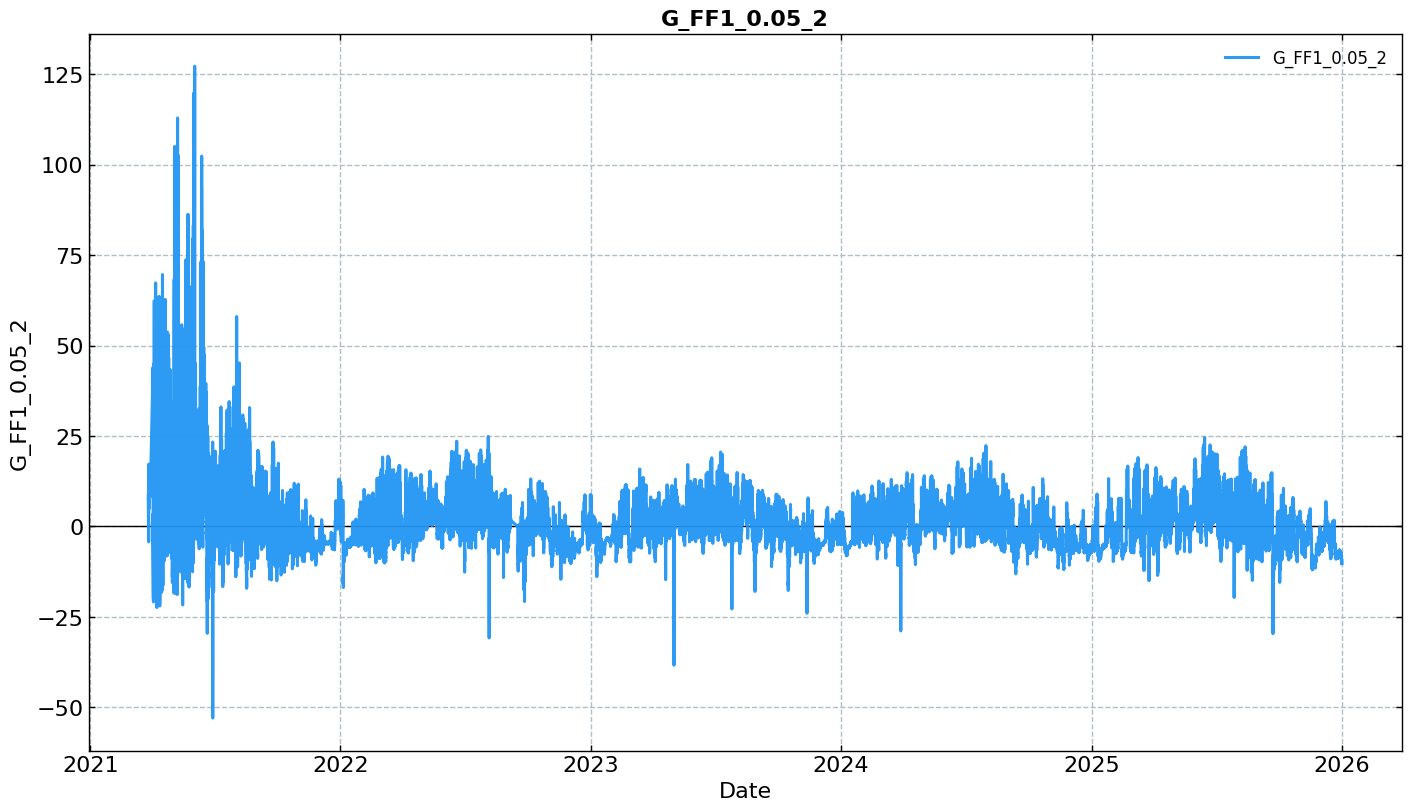

In [22]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## ▶️ Start MeteoScreening with `diive`
`showplot_orig()` shows the raw series. If it needs no outlier removal, skip *Outlier detection* and continue at *Corrections* or *Resampling*. Skip the `QCF` section too, because `finalize_outlier_detection()` raises when no test has run.

> Validating data for variable G_FF1_0.05_2 ...

> Found 2 unique frequencies across 2478903 records.

> Found frequencies:

> The following frequencies will be used: [60.0] (seconds)

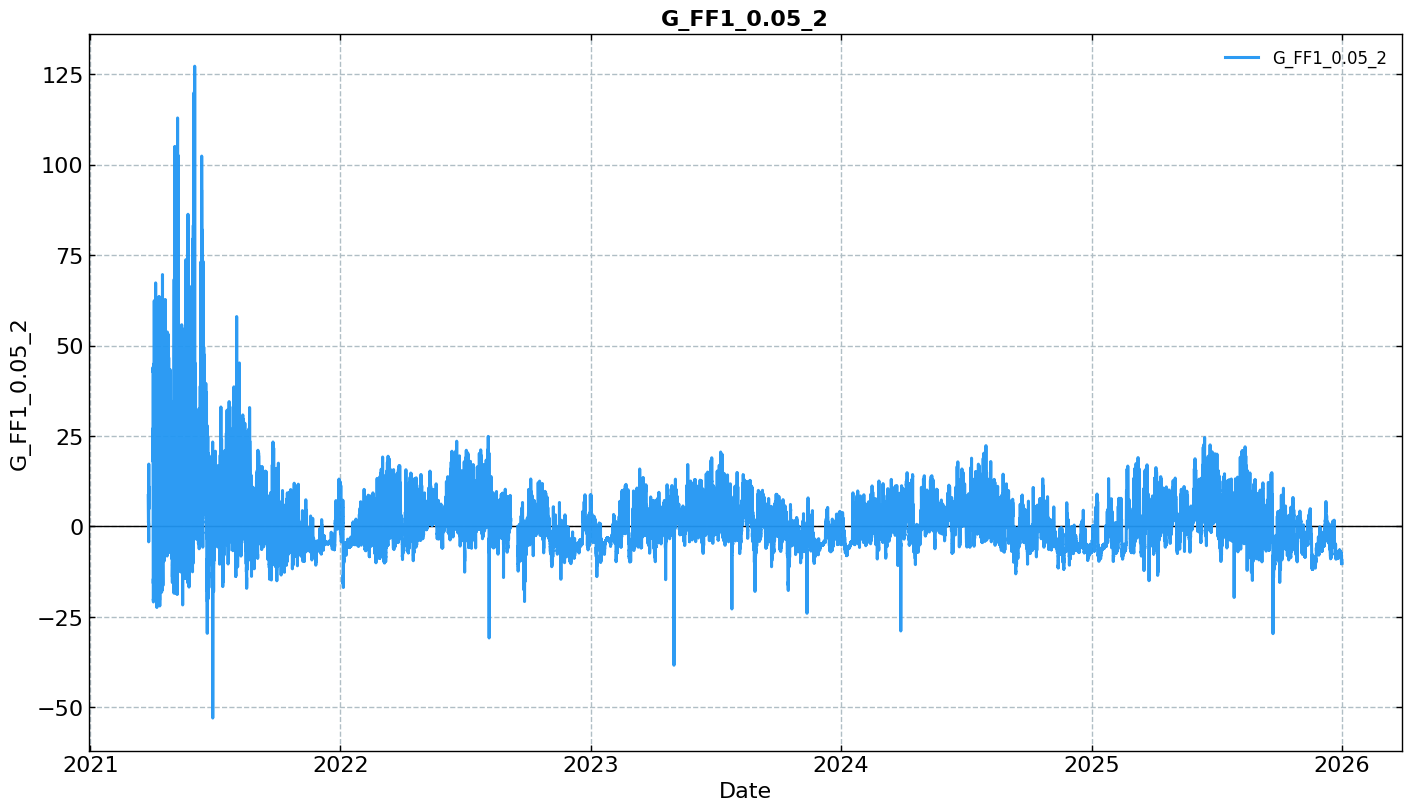

In [23]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Each method has a test cell and an `mscr.addflag()` cell. Run the test as often as you like with different settings and look at the preview. Only `mscr.addflag()` commits the flag, and it commits the most recent test. Run only the methods your variable needs.

`separate_day_night=True` uses separate thresholds for day and night. The boundary comes from the site coordinates given above.

In [24]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable G_FF1_0.05_2 ...

Plot the current cleaned data at any point during detection. `interactive=True` opens a Bokeh plot in the browser instead, with hover and zoom. `showplot_orig()` and `showplot_cleaned()` take the same argument.

In [26]:
mscr.showplot_outlier_detection_cleaned(interactive=True)

### Manual removal
Removes given timestamps or time ranges. Use it for known sensor failures and maintenance periods. A single timestamp matches nothing, so write a range that brackets the record (see *Timestamp convention*). For all parameters run `help(dv.outliers.ManualRemoval)`.

In [ ]:
REMOVE_DATES = [
    ['2021-01-01 00:15:00', '2021-12-31 23:45:00'],
]
mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)

In [ ]:
mscr.addflag()

### Hampel filter
Spike detection in a sliding window, using the median absolute deviation. It is a good general-purpose filter and is not thrown off by spikes already inside the window. For all parameters run `help(dv.outliers.Hampel)`.

In [ ]:
mscr.flag_outliers_hampel_test(
    window_length=60 * 24 * 7,  # records per window
    n_sigma_daytime=5.5, n_sigma_nighttime=5.5,
    use_differencing=True, separate_day_night=True,
    repeat=True, showplot=True, verbose=True,
)

In [ ]:
mscr.addflag()

### Z-score
Flags values further from the mean than `thres_zscore` standard deviations. It uses the whole record, so it responds to the seasonal cycle as well as to faults. Some variables have valid values below zero or above a nominal maximum, and those are handled in *Corrections*, so check the preview before committing. For all parameters run `help(dv.outliers.zScore)`.

In [ ]:
mscr.flag_outliers_zscore_test(
    thres_zscore=4.5, separate_day_night=True,
    repeat=True, showplot=True, verbose=True,
)

In [ ]:
mscr.addflag()

### Z-score (rolling window)
The same test in a moving window of `winsize` records. It follows slow drifts and flags only local spikes. For all parameters run `help(dv.outliers.zScoreRolling)`.

In [28]:
# mscr.flag_outliers_zscore_rolling_test(
#     thres_zscore=4.5, winsize=60 * 24 * 7,
#     repeat=False, showplot=True, verbose=True,
# )

In [ ]:
mscr.addflag()

### Local standard deviation
Flags values further than `n_sd` standard deviations from a rolling window of `winsize` records. `constant_sd=True` uses one standard deviation for the whole record instead of one per window. For all parameters run `help(dv.outliers.LocalSD)`.

In [ ]:
mscr.flag_outliers_localsd_test(
    separate_day_night=True, n_sd=5.5, winsize=60 * 24 * 7,
    constant_sd=False, repeat=False, showplot=True, verbose=True,
)

In [ ]:
mscr.addflag()

### Increments z-score
Flags jumps between consecutive records that are too large. It catches spikes and steps that tests on the value itself miss. Differences are computed after missing records are dropped, so the records on either side of a gap are compared across it. For all parameters run `help(dv.outliers.zScoreIncrements)`.

In [ ]:
mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)

In [ ]:
mscr.addflag()

### Local outlier factor
Density-based detection using nearest neighbours. Flags points that sit apart from their neighbours. Slow on high-resolution data, so use it on 30MIN or coarser. For all parameters run `help(dv.outliers.LocalOutlierFactor)`.

In [ ]:
mscr.flag_outliers_lof_test(
    n_neighbors=30, contamination=0.01, separate_day_night=False,
    repeat=False, n_jobs=-1, showplot=True, verbose=True,
)

In [ ]:
mscr.addflag()

### Absolute limits
Flags values outside the fixed range `[minval, maxval]`. For separate day and night ranges set `minval_daytime`, `maxval_daytime`, `minval_nighttime` or `maxval_nighttime`. Setting any of those turns the day/night split on. For all parameters run `help(dv.outliers.AbsoluteLimits)`.

> running AbsoluteLimits ...

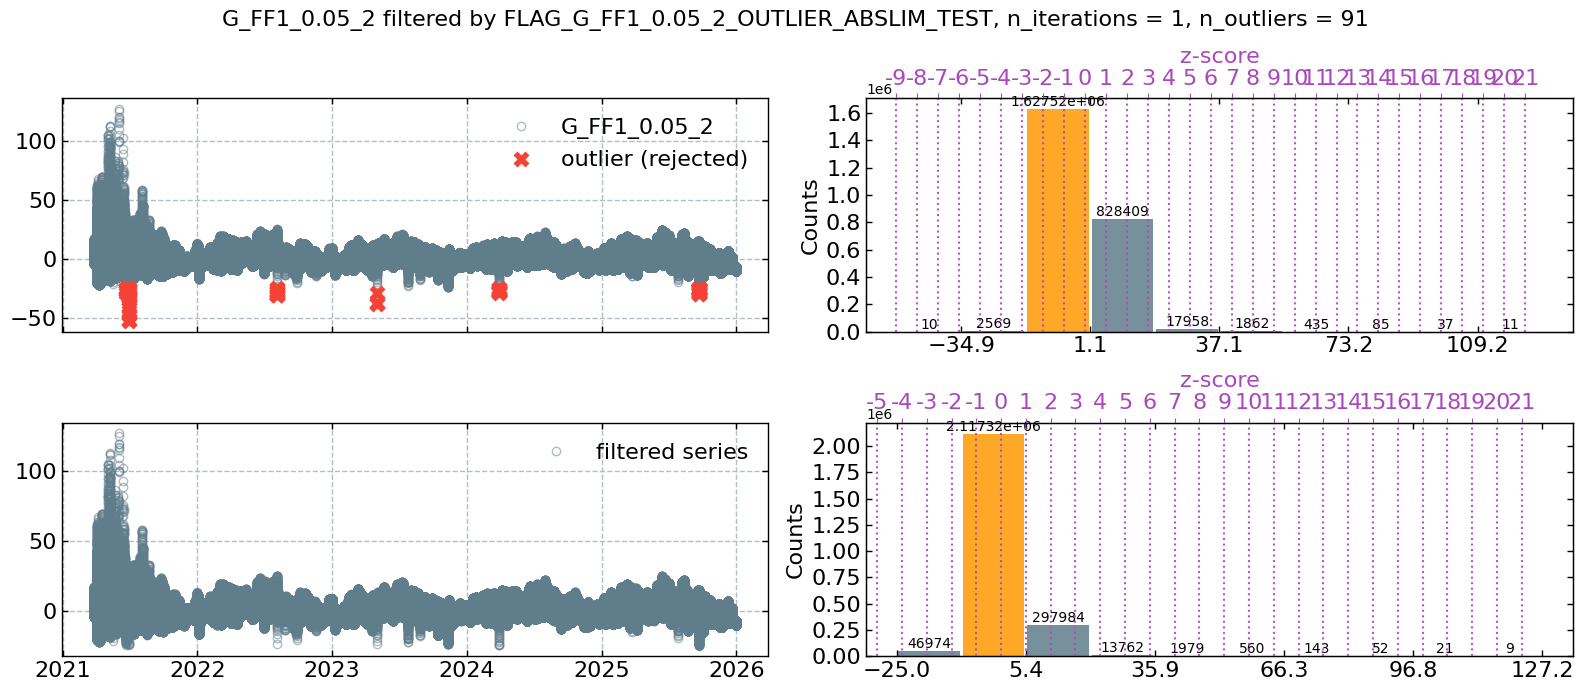

In [29]:
mscr.flag_outliers_abslim_test(minval=-25, maxval=999, showplot=True, verbose=True)

In [30]:
mscr.addflag()

> ++Added flag column FLAG_G_FF1_0.05_2_OUTLIER_ABSLIM_TEST to flag data

### Trim low
Flags values below `lower_limit`, then flags the same number of the highest values, so the trim is symmetric. `trim_daytime` and `trim_nighttime` choose which period is trimmed. For all parameters run `help(dv.outliers.TrimLow)`.

In [ ]:
mscr.flag_outliers_trim_low_test(
    trim_daytime=False, trim_nighttime=True, lower_limit=10,
    showplot=True, verbose=True,
)

In [ ]:
mscr.addflag()

### Missing values
Not an outlier test. It flags missing records so they are counted in `QCF`. There is no `addflag()` here.

In [31]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_G_FF1_0.05_2_MISSING_TEST, newly 
calculated from variable G_FF1_0.05_2, with flag 0 (good values) where G_FF1_0.05_2 is available, 
flag 2 (bad values) where G_FF1_0.05_2 is missing.

### Overall quality flag QCF
Aggregate all committed flags into one flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Run this before corrections and resampling.

In [32]:
mscr.finalize_outlier_detection()

#### Reports

In [33]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: G_FF1_0.05_2

...

(count)      (count)                          
0/1/2

----------------------------------------------------------------------------------------------------
--------------------

1     G_FF1_0.05_2_MISSING                   0        2478898      0            100.00    0.00      
2478898/0/0

2     G_FF1_0.05_2_OUTLIER_ABSLIM            91       2478807      91           100.00    0.00      
2478807/0/91

====================================================================================================
====================

In [34]:
mscr.report_outlier_detection_qcf_flags()

====================================================================================================

INDIVIDUAL TEST FLAG STATISTICS: G_FF1_0.05_2

====================================================================================================

Total test flags: 2

+- REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

+- G_FF1_0.05_2_OUTLIER_ABSLIM

|  Period          | Pass (0)        | Warn (1)        | Fail (2)        | Missing

|  -------------------------------------------------------------------------------------

|  OVERALL         | 2478807 (100.0%) |     0 (  0.0%)  |    91 (  0.0%)  |    0 (  0.0%)

====================================================================================================

In [35]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: G_FF1_0.05_2

======================================================================

[1] TIME PERIOD

Start:  2021-03-26 15:21

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2478807/2478898 (100.00%)

Data loss from QC:         91/2478898 (0.00%)

Final data coverage:       2478807/2507559 (98.85% of potential)

======================================================================

#### Plots

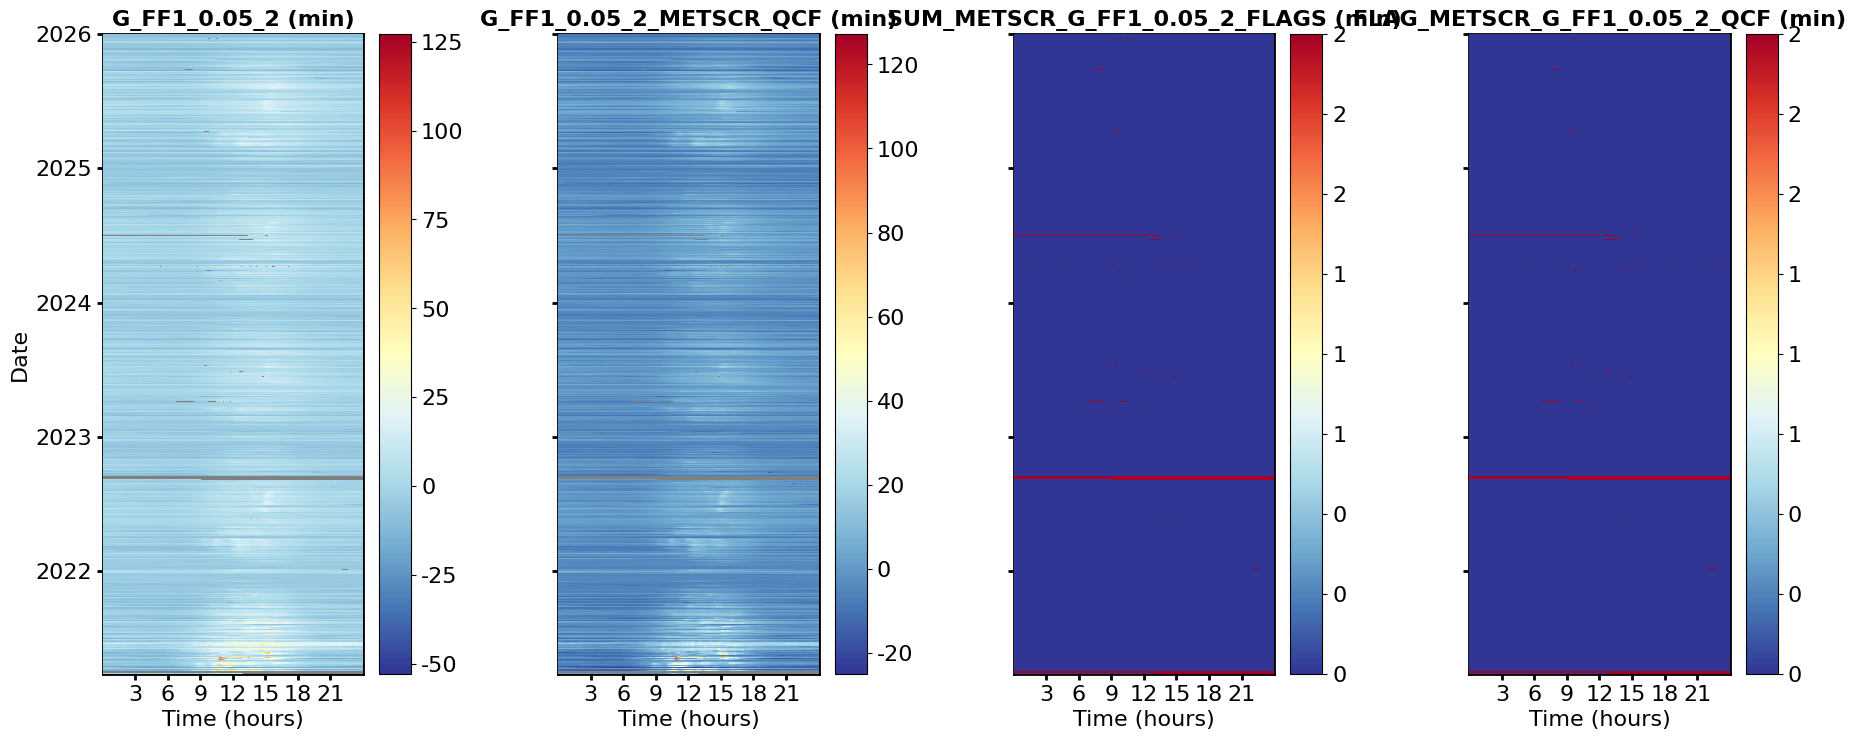

In [36]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. Run only what applies to your variable.

Every call below is commented out on purpose. Each one changes the data using example settings, so a top-to-bottom *Run All* would otherwise alter values that should not be touched. Edit the settings, then uncomment the call.

In [ ]:
mscr.showplot_cleaned()

### Remove radiation zero offset
For incoming and outgoing shortwave and PAR. Finds the nighttime offset per day, sets night to zero, and shifts daytime values by the interpolated offset.

In [ ]:
# mscr.correction_remove_nighttime_zero_offset()

### Remove relative humidity offset
Removes the offset so values do not exceed 100%.

In [ ]:
# mscr.correction_remove_relativehumidity_offset()

### Set to maximum or minimum threshold
Sets values above (or below) a threshold to the threshold itself. This replaces a bad value with a plausible one that nothing downstream can identify as false. Removing the value is usually better.

In [ ]:
# mscr.correction_setto_max_threshold(threshold=30)
# mscr.correction_setto_min_threshold(threshold=-5)

### Set a time range to a value
Sets all records in the given date ranges to one value.

In [ ]:
DATES = [
    ['2022-04-01', '2022-04-05'],
]
# mscr.correction_setto_value(dates=DATES, value=3.7, verbose=1)
# mscr.showplot_cleaned(interactive=False)

### Set exact values to missing
Sets records equal to the given values to `NaN`, for example a stuck reading. Check the most frequent values first. The inspection below only reads the data.

In [ ]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

In [ ]:
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 📈 Analyses (optional)

### Check for timestamp shifts
For radiation variables. Compares the measured series against potential radiation, day by day. A steady offset between the two points to a shifted timestamp.

In [ ]:
# _ = mscr.analysis_potential_radiation_correlation(
#     utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS, mincorr=0.7, showplot=True)

## 🔁 Resampling

### Resample
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again, ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

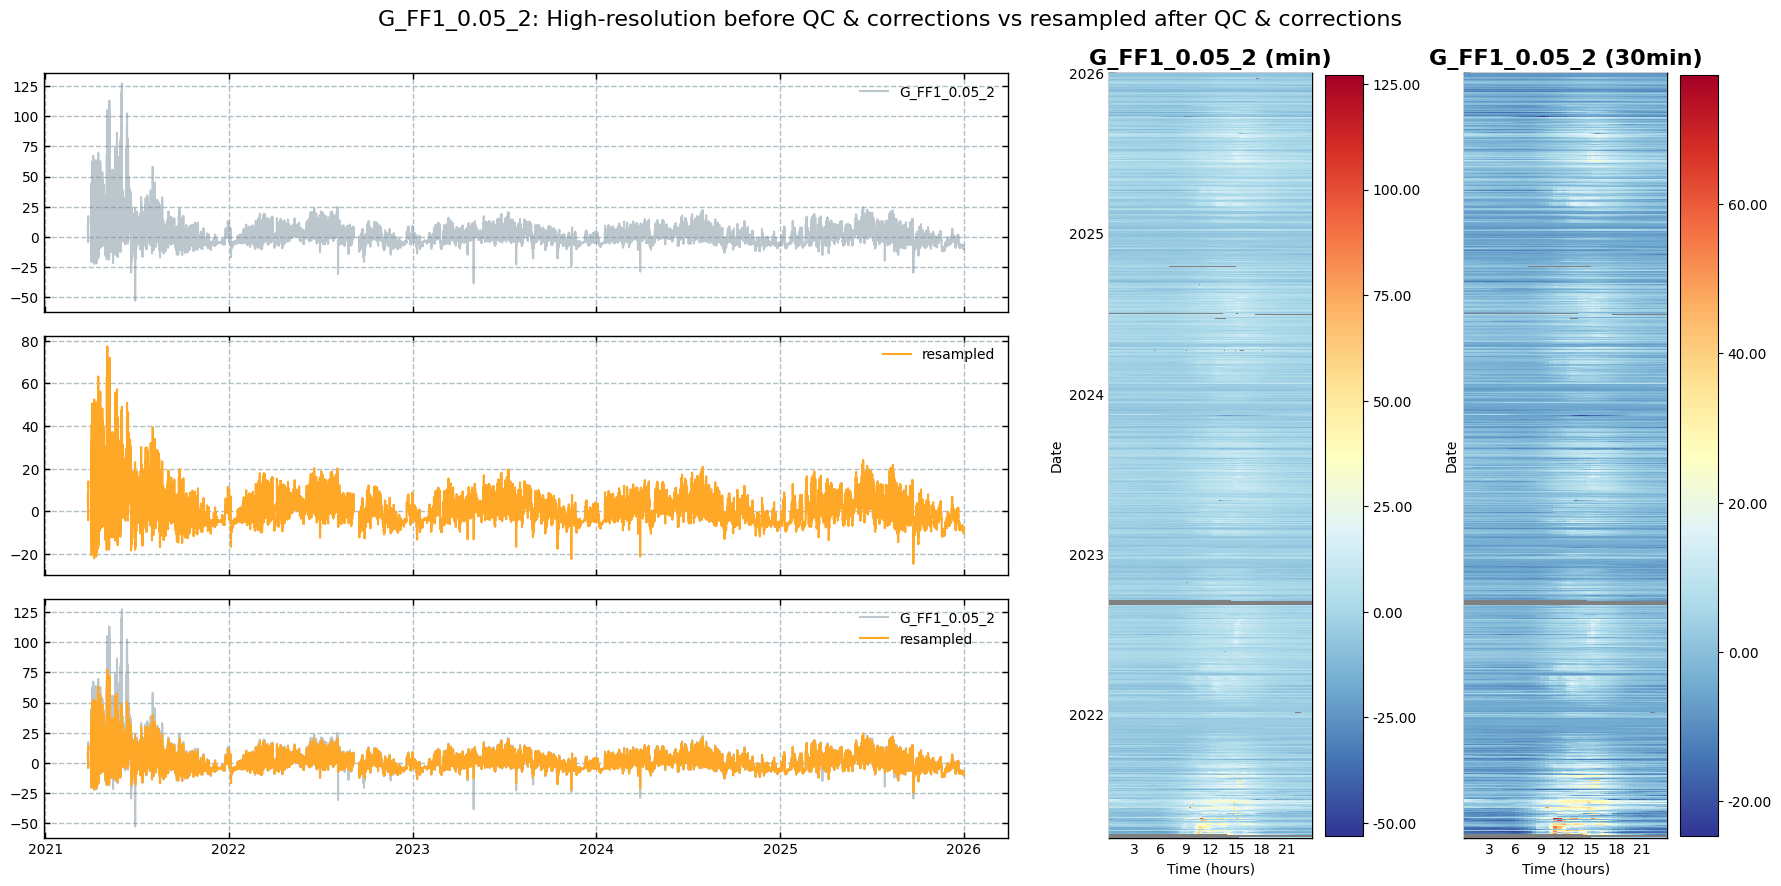

In [37]:
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [38]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - G_FF1_0.05_2: 30min


## ⬆️ Upload data to database

Re-uploading overwrites the same variant, so it is safe to re-run. With `delete_from_db_before_upload=True` the upload first deletes, then writes. The delete matches `_measurement` plus `varname` plus `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its own previous result. It does not touch the raw data, other variables, or other data versions.

The delete matters because InfluxDB keys a point by its full tag set. If a tag changed between runs, a plain overwrite would leave the old point in place as a duplicate. The delete removes the old point regardless of its tags.

In [39]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['G_FF1_0.05_2'] between 2021-03-26T15:30:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['G'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['G_FF1_0.05_2']

v Upload finished.

### Verify upload
Download the uploaded data again and check its time resolution and timestamps. They should be local `TIMESTAMP_END`, matching what was screened.

In [40]:
# Fresh names so the screened originals are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['G_FF1_0.05_2'] from measurements ['G'], 
data version ['meteoscreening_diive'], between 2021-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

,G_FF1_0.05_2
TIMESTAMP_END,
2021-03-26 15:30:00,8.333178
2021-03-26 16:00:00,7.502525
2021-03-26 16:30:00,6.863993
2021-03-26 17:00:00,6.405742
2021-03-26 17:30:00,6.071823
...,...
2025-12-31 22:00:00,-10.083217
2025-12-31 22:30:00,-10.118965
2025-12-31 23:00:00,-10.165545


In [41]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - G_FF1_0.05_2: freq=30min, first=2021-03-26 15:30:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [42]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-09-03 01:05:10
